# Policy-Triggered Decay: Comparison (10k steps)

**3 baselines** — fixed `wsd_s` decay at step 7k / 8k / 9k (out of 10 000 total steps)  
**3 policies** — `warmup_stable` schedule, policy-triggered decay, can fire from step 7000 onwards

| Run | Type | Trigger logic |
|-----|------|---------------|
| baseline_7k | fixed | decay at step 7000 |
| baseline_8k | fixed | decay at step 8000 |
| baseline_9k | fixed | decay at step 9000 |
| loss_variance | `loss_variance_low` | `val_loss < gate` **and** `loss_variance < threshold` |
| grad_snr | `grad_snr_low` | `val_loss < gate` **and** `grad_snr < threshold` |
| combined | `combined` | `val_loss < gate` **and** both metric conditions |


In [22]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

In [23]:
LOG_ROOT = Path("../logs")

RUNS = {
    "baseline_7k":   "policy_decay_baseline_10k_7k_20260610-204423",
    "baseline_8k":   "policy_decay_baseline_10k_8k_20260610-080323",
    "baseline_9k":   "policy_decay_baseline_10k_9k_20260610-080329",
    "loss_variance": "policy_decay_loss_variance_10k_20260610-223455",
    "grad_snr":      "policy_decay_grad_snr_10k_20260610-223421",
    "combined":      "policy_decay_combined_10k_20260610-080334",
}
FIXED_TRIGGERS = {
    "baseline_7k": 7000,
    "baseline_8k": 8000,
    "baseline_9k": 9000,
}
COLORS = {
    "baseline_7k":   "black",
    "baseline_8k":   "dimgray",
    "baseline_9k":   "darkgray",
    "loss_variance": "steelblue",
    "grad_snr":      "darkorange",
    "combined":      "mediumpurple",
}
DISPLAY_NAMES = {
    "baseline_7k":   "Baseline (7k)",
    "baseline_8k":   "Baseline (8k)",
    "baseline_9k":   "Baseline (9k)",
    "loss_variance": "Loss variance",
    "grad_snr":      "Grad SNR",
    "combined":      "Combined",
}
VAL_LOSS_GATE = 3.585
EARLIEST_TRIGGER = 7000

def read_jsonl(path):
    with open(path) as f:
        return pd.DataFrame(json.loads(line) for line in f if line.strip())

data = {}
for key, folder in RUNS.items():
    log_dir = LOG_ROOT / folder
    assert log_dir.exists(), f"Run folder not found: {log_dir}"
    metrics = read_jsonl(log_dir / "metrics.jsonl")
    trigger = None
    if (log_dir / "policy_trigger.json").exists():
        with open(log_dir / "policy_trigger.json") as f:
            trigger = json.load(f)
    elif key in FIXED_TRIGGERS:
        trigger = {"trigger_step": FIXED_TRIGGERS[key]}
    data[key] = {
        "log_dir": log_dir,
        "metrics": metrics,
        "train": metrics[metrics["train_loss"].notna()].reset_index(drop=True),
        "val":   metrics[metrics["validation_loss"].notna()].reset_index(drop=True),
        "trigger": trigger,
    }

for key, d in data.items():
    t = d["trigger"]
    trig_str = f"step {t['trigger_step']}" if t else "none"
    final_val = d["val"]["validation_loss"].iloc[-1]
    print(f"{key:15s}  trigger={trig_str:14s}  val_rows={len(d['val']):3d}  final_val={final_val:.4f}")

baseline_7k      trigger=step 7000       val_rows=200  final_val=3.4363
baseline_8k      trigger=step 8000       val_rows=200  final_val=3.4302
baseline_9k      trigger=step 9000       val_rows=200  final_val=3.4263
loss_variance    trigger=step 7010       val_rows=200  final_val=3.4362
grad_snr         trigger=step 7010       val_rows=200  final_val=3.4348
combined         trigger=step 7010       val_rows=200  final_val=3.4371


## Overview

In [24]:
rows = []
for key, d in data.items():
    final_val = d["val"]["validation_loss"].iloc[-1]
    trig_step = d["trigger"]["trigger_step"] if d["trigger"] else None
    rows.append({
        "run": key,
        "trigger_step": trig_step,
        "trigger_%": f"{100 * trig_step / 10000:.0f}%" if trig_step else "—",
        "final_val_loss": final_val,
    })

summary = pd.DataFrame(rows).set_index("run")
baseline_vals = summary.loc[[k for k in summary.index if k.startswith("baseline")], "final_val_loss"]
best_baseline = baseline_vals.min()
summary["Δ vs best baseline"] = summary["final_val_loss"] - best_baseline
display(summary.style.background_gradient(
    subset=["final_val_loss", "Δ vs best baseline"], cmap="RdYlGn_r"
))


,trigger_step,trigger_%,final_val_loss,Δ vs best baseline
run,,,,
baseline_7k,7000,70%,3.436261,0.009989
baseline_8k,8000,80%,3.430223,0.003951
baseline_9k,9000,90%,3.426272,0.000000
loss_variance,7010,70%,3.436192,0.009920
grad_snr,7010,70%,3.434769,0.008497
combined,7010,70%,3.437057,0.010786


## Validation Loss Curves + Trigger Points

Dashed vertical lines mark the step at which each policy triggered decay (or step 6300 for the baseline). The shape of the curves after each trigger shows how quickly the loss drops under the respective decay schedule.

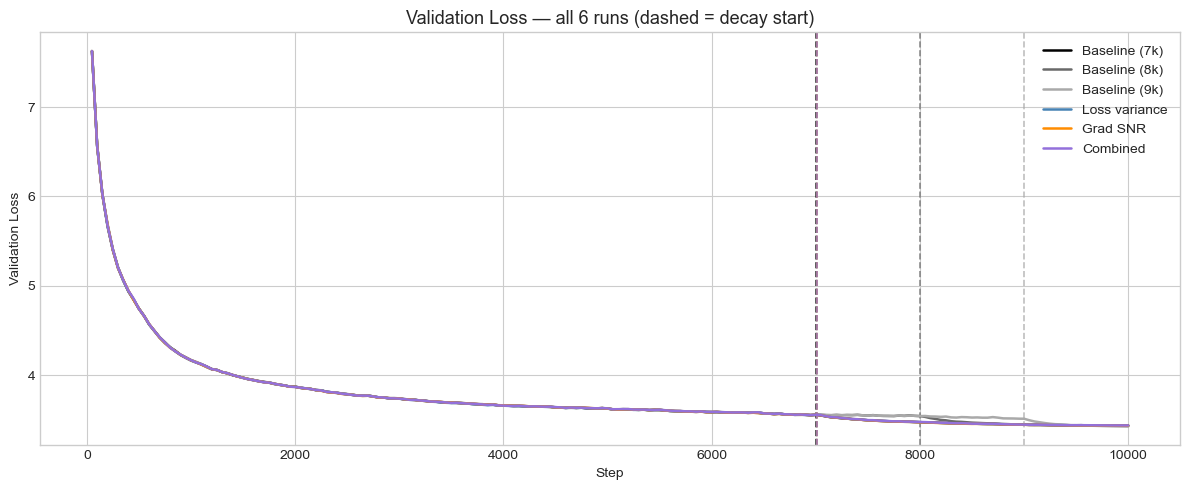

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))

for key, d in data.items():
    val = d["val"]
    trig_step = d["trigger"]["trigger_step"] if d["trigger"] else None
    ax.plot(val["step"], val["validation_loss"],
            color=COLORS[key], linewidth=1.8, label=DISPLAY_NAMES[key])
    if trig_step:
        ax.axvline(trig_step, color=COLORS[key], linewidth=1.2, linestyle="--", alpha=0.75)

ax.set_xlabel("Step")
ax.set_ylabel("Validation Loss")
ax.set_title("Validation Loss — all 6 runs (dashed = decay start)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## Learning Rate Schedules

Shows when each policy's decay actually kicked in and the shape of the decay curve. Policies that trigger earlier have a longer decay window.

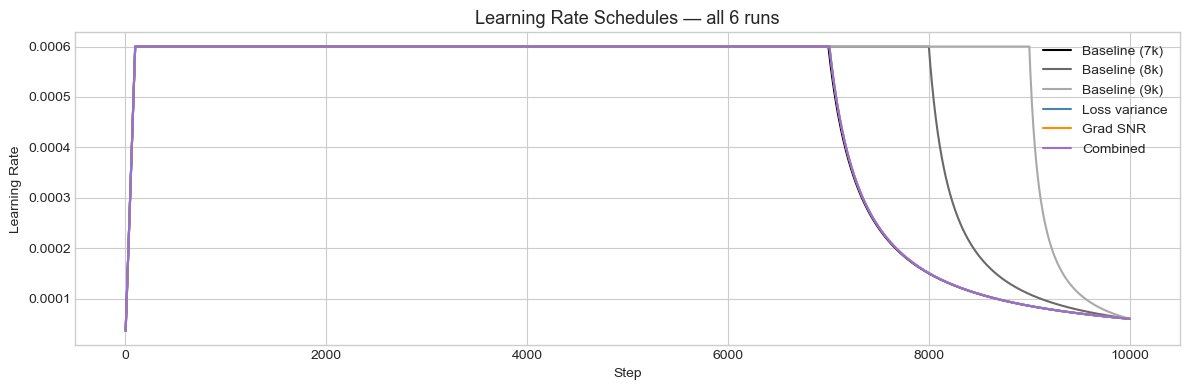

In [26]:
fig, ax = plt.subplots(figsize=(12, 4))

for key, d in data.items():
    train = d["train"]
    ax.plot(train["step"], train["learning_rate"],
            color=COLORS[key], linewidth=1.5, label=DISPLAY_NAMES[key])

ax.set_xlabel("Step")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedules — all 6 runs", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## Why Did Each Policy Trigger?

For each policy run, two conditions must both be true before decay fires:
1. **Gate**: `validation_loss < 3.9` (model must have genuinely entered plateau territory)
2. **Metric condition**: policy-specific threshold

The plots below show:
- The triggering metric over time (solid line)
- The threshold (horizontal dashed line)
- Where the `val_loss_gate` was first crossed (gray vertical line)
- Where the policy actually triggered (colored vertical line)
- The validation loss curve (right panel) with the same two markers

The gap between the gray and colored lines reveals whether the *gate* or the *metric condition* was the binding constraint.

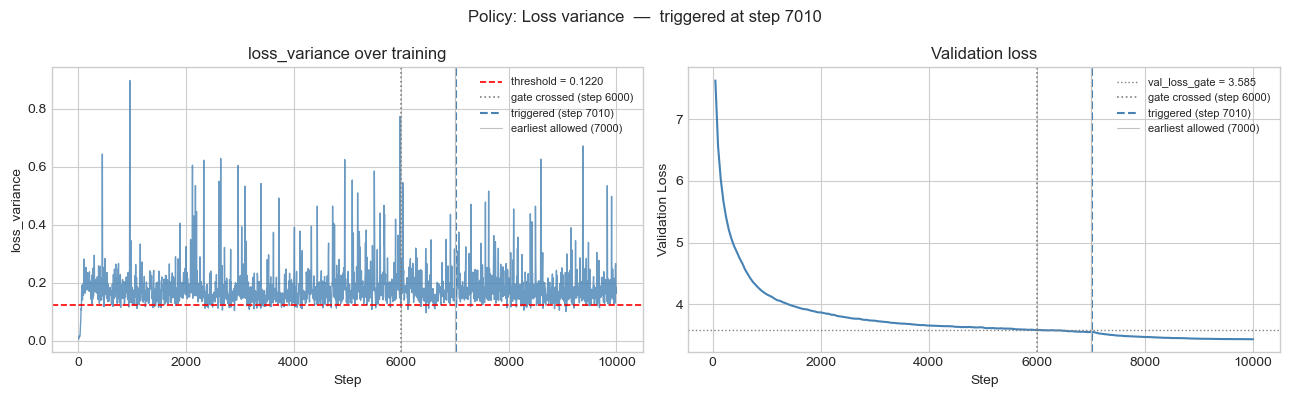

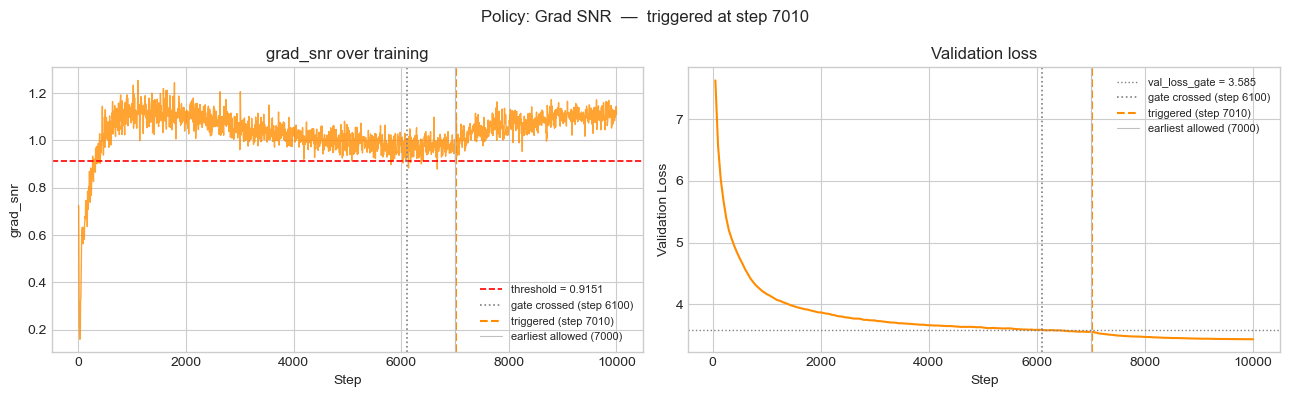

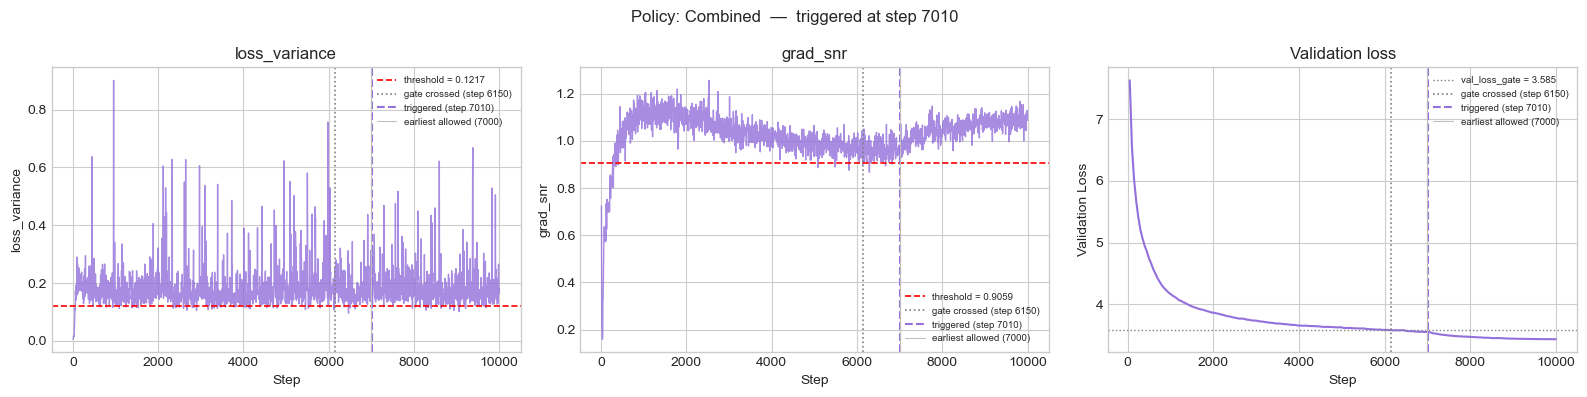

In [27]:
def _gate_step(val_df, gate=VAL_LOSS_GATE):
    below = val_df[val_df["validation_loss"] < gate]
    return int(below["step"].iloc[0]) if len(below) > 0 else None

def _draw_trigger_lines(ax, gate_s, trig_s, color):
    if gate_s is not None:
        ax.axvline(gate_s, color="gray", linewidth=1.2, linestyle=":",
                   label=f"gate crossed (step {gate_s})")
    if trig_s is not None:
        ax.axvline(trig_s, color=color, linewidth=1.5, linestyle="--",
                   label=f"triggered (step {trig_s})")
    ax.axvline(EARLIEST_TRIGGER, color="silver", linewidth=0.8, linestyle="-",
               label=f"earliest allowed ({EARLIEST_TRIGGER})")

# ----- loss_variance and grad_snr -----
for key, metric_col in [("loss_variance", "loss_variance"), ("grad_snr", "grad_snr")]:
    d = data[key]
    trigger = d["trigger"]
    trig_s = trigger["trigger_step"] if trigger else None
    threshold = trigger.get("computed_thresholds", {}).get(f"{metric_col}_threshold")
    gate_s = _gate_step(d["val"])
    color = COLORS[key]

    fig, (ax_m, ax_v) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"Policy: {DISPLAY_NAMES[key]}  —  triggered at step {trig_s}", fontsize=12)

    train = d["train"]
    ax_m.plot(train["step"], train[metric_col], color=color, linewidth=1, alpha=0.8)
    if threshold is not None:
        ax_m.axhline(threshold, color="red", linewidth=1.2, linestyle="--",
                     label=f"threshold = {threshold:.4f}")
    _draw_trigger_lines(ax_m, gate_s, trig_s, color)
    ax_m.set_xlabel("Step"); ax_m.set_ylabel(metric_col)
    ax_m.set_title(f"{metric_col} over training")
    ax_m.legend(fontsize=8)

    val = d["val"]
    ax_v.plot(val["step"], val["validation_loss"], color=color, linewidth=1.5)
    ax_v.axhline(VAL_LOSS_GATE, color="gray", linewidth=1, linestyle=":",
                 label=f"val_loss_gate = {VAL_LOSS_GATE}")
    _draw_trigger_lines(ax_v, gate_s, trig_s, color)
    ax_v.set_xlabel("Step"); ax_v.set_ylabel("Validation Loss")
    ax_v.set_title("Validation loss")
    ax_v.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# ----- combined (3 panels) -----
key = "combined"
d = data[key]
trigger = d["trigger"]
trig_s = trigger["trigger_step"] if trigger else None
gate_s = _gate_step(d["val"])
color = COLORS[key]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Policy: Combined  —  triggered at step {trig_s}", fontsize=12)

train = d["train"]
for ax, metric_col in [(ax1, "loss_variance"), (ax2, "grad_snr")]:
    threshold = trigger.get("computed_thresholds", {}).get(f"{metric_col}_threshold")
    ax.plot(train["step"], train[metric_col], color=color, linewidth=1, alpha=0.8)
    if threshold is not None:
        ax.axhline(threshold, color="red", linewidth=1.2, linestyle="--",
                   label=f"threshold = {threshold:.4f}")
    _draw_trigger_lines(ax, gate_s, trig_s, color)
    ax.set_xlabel("Step"); ax.set_ylabel(metric_col)
    ax.set_title(metric_col)
    ax.legend(fontsize=7)

ax3.plot(d["val"]["step"], d["val"]["validation_loss"], color=color, linewidth=1.5)
ax3.axhline(VAL_LOSS_GATE, color="gray", linewidth=1, linestyle=":",
            label=f"val_loss_gate = {VAL_LOSS_GATE}")
_draw_trigger_lines(ax3, gate_s, trig_s, color)
ax3.set_xlabel("Step"); ax3.set_ylabel("Validation Loss")
ax3.set_title("Validation loss")
ax3.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Metric State at Trigger

For each policy run, we look up all tracked metrics at the trigger step and normalize them to [0, 1] over their observed training range. This shows whether policies fired in "similar" model states, and which metric dimensions differ across trigger events.

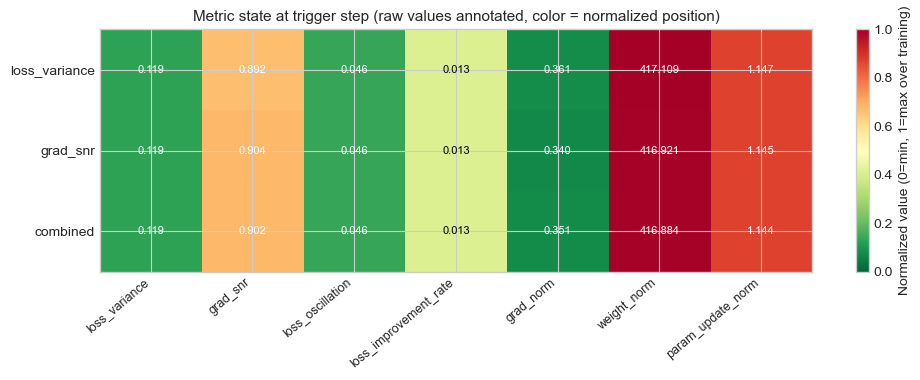


Raw snapshot values at trigger step:


,loss_variance,grad_snr,loss_oscillation,loss_improvement_rate,grad_norm,weight_norm,param_update_norm
loss_variance,0.118690,0.891540,0.045966,0.012567,0.361244,417.109222,1.147238
grad_snr,0.119265,0.903748,0.045581,0.012645,0.339678,416.920959,1.144530
combined,0.119123,0.902117,0.045664,0.012650,0.350765,416.884125,1.143602


In [28]:
TRACKED_METRICS = [
    "loss_variance", "grad_snr", "loss_oscillation",
    "loss_improvement_rate", "grad_norm", "weight_norm", "param_update_norm",
]
POLICY_KEYS = ["loss_variance", "grad_snr", "combined"]

snapshot_rows = {}
for key in POLICY_KEYS:
    d = data[key]
    trig_s = d["trigger"]["trigger_step"] if d["trigger"] else None
    if trig_s is None:
        continue
    train = d["train"]
    idx = (train["step"] - trig_s).abs().idxmin()
    snapshot_rows[key] = train.loc[idx, [m for m in TRACKED_METRICS if m in train.columns]]

snapshot_df = pd.DataFrame(snapshot_rows).T

norm_df = snapshot_df.copy()
for col in norm_df.columns:
    all_vals = pd.concat([data[k]["train"][col] for k in POLICY_KEYS if col in data[k]["train"].columns])
    lo, hi = all_vals.min(), all_vals.max()
    norm_df[col] = (snapshot_df[col] - lo) / (hi - lo + 1e-12)

fig, ax = plt.subplots(figsize=(len(norm_df.columns) * 1.3 + 1, len(norm_df) * 0.8 + 1.5))
im = ax.imshow(norm_df.values, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Normalized value (0=min, 1=max over training)")
ax.set_xticks(range(len(norm_df.columns)))
ax.set_xticklabels(norm_df.columns, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(len(norm_df.index)))
ax.set_yticklabels(norm_df.index, fontsize=10)
for i in range(len(norm_df.index)):
    for j in range(len(norm_df.columns)):
        v = norm_df.values[i, j]
        ax.text(j, i, f"{snapshot_df.values[i, j]:.3f}", ha="center", va="center",
                fontsize=8, color="white" if v > 0.6 or v < 0.25 else "black")
ax.set_title("Metric state at trigger step (raw values annotated, color = normalized position)", fontsize=11)
plt.tight_layout()
plt.show()

print("\nRaw snapshot values at trigger step:")
display(snapshot_df.style.background_gradient(cmap="RdYlGn_r", axis=0))


## Decay Window Zoom (steps 6500–10000)

The key comparison: how does validation loss evolve in the decay window for each run? Trigger points are marked. Policy runs that fire earlier have more steps at reduced LR.


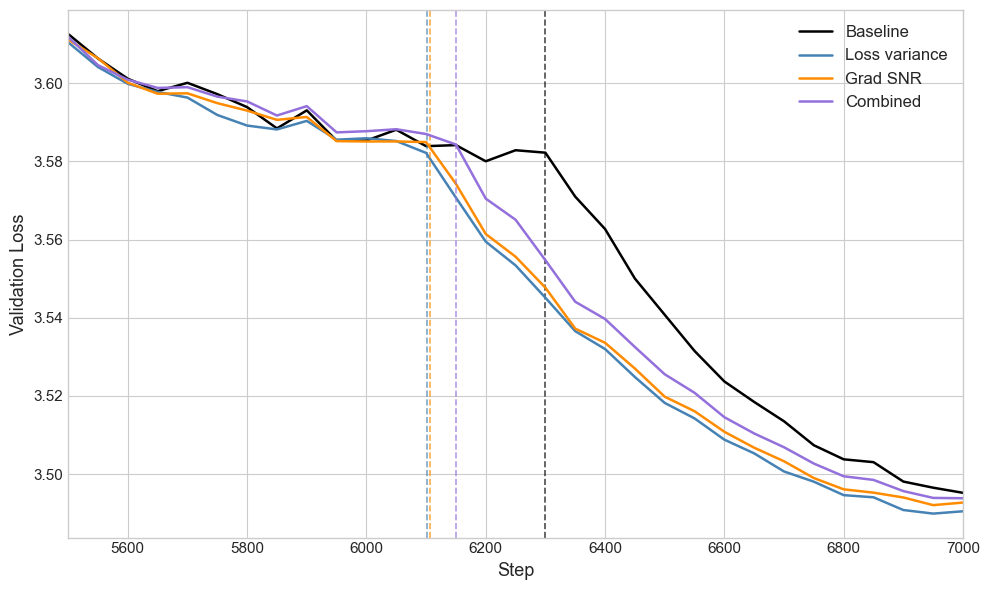

In [34]:
ZOOM_START = 6500

fig, ax = plt.subplots(figsize=(10, 6))

for key, d in data.items():
    val = d["val"]
    mask = val["step"] >= ZOOM_START
    trig_step = d["trigger"]["trigger_step"] if d["trigger"] else None
    ax.plot(val.loc[mask, "step"], val.loc[mask, "validation_loss"],
            color=COLORS[key], linewidth=1.8, label=DISPLAY_NAMES[key])
    if trig_step:
        ax.axvline(trig_step, color=COLORS[key], linewidth=1.2, linestyle="--", alpha=0.7)
ax.set_xlim(ZOOM_START)
ax.set_xlabel("Step", fontsize=13)
ax.set_ylabel("Validation Loss", fontsize=13)
ax.tick_params(labelsize=11)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Trigger Timing vs Final Loss

Direct tradeoff plot: does an earlier decay start lead to a better final validation loss?

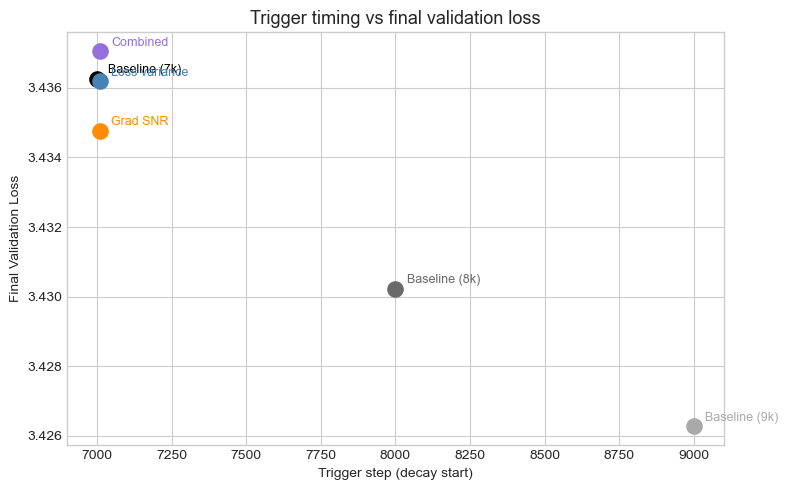

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

for key, d in data.items():
    final_val = d["val"]["validation_loss"].iloc[-1]
    trig_step = d["trigger"]["trigger_step"] if d["trigger"] else None
    if trig_step is None:
        continue
    ax.scatter(trig_step, final_val, color=COLORS[key], s=120, zorder=4)
    ax.annotate(DISPLAY_NAMES[key], (trig_step, final_val),
                textcoords="offset points", xytext=(8, 4), fontsize=9, color=COLORS[key])

ax.set_xlabel("Trigger step (decay start)")
ax.set_ylabel("Final Validation Loss")
ax.set_title("Trigger timing vs final validation loss", fontsize=13)
plt.tight_layout()
plt.show()

## Interpretation Checklist

Look for:

- **Did any policy beat the baseline?** Check the Δ vs baseline column in the overview table and the zoom plot.
- **Which policy triggered earliest / latest?** Earlier trigger = longer decay, potentially better if the model had already plateaued. Later trigger = shorter decay, potentially better if more stable training steps were needed.
- **Was the `val_loss_gate` binding?** In the trigger diagnostic plots: if the gray line (gate crossed) appears well after `step 4900`, the gate was the bottleneck, not the metric condition. If the metric condition line appears after the gray line, the metric was the bottleneck.
- **Did policies fire in similar model states?** Check the metric snapshot heatmap — if rows look similar, all policies "agree" on the model's state at trigger time.
- **Is `combined` the most conservative?** It requires two conditions simultaneously, so it should trigger latest. Does waiting for the "clearest" signal pay off?
- **`loss_variance` vs `grad_snr`**: both proxy for training stability but from different angles (loss noise vs gradient quality). Which catches the plateau first? Which final loss is better?

## Loss Improvement vs Effective Decay Steps

Policies that trigger late have fewer actual decay steps before training ends (e.g. combined triggered at 6150 → only 550 out of 700 decay steps completed). This cell normalizes for that by computing:

- **Effective decay steps** = min(decay_length, max_steps − trigger_step)
- **Loss improvement** = val_loss just before decay − final val_loss
- **Improvement efficiency** = loss improvement / effective decay steps

,trigger_step,effective_decay_steps,val_at_trigger,final_val_loss,loss_improvement,improvement_per_step
run,,,,,,
baseline_7k,7000,1000,3.556046,3.436261,0.119785,0.000120
baseline_8k,8000,1000,3.541762,3.430223,0.111539,0.000112
baseline_9k,9000,1000,3.512214,3.426272,0.085942,0.000086
loss_variance,7010,1000,3.556801,3.436192,0.120609,0.000121
grad_snr,7010,1000,3.556672,3.434769,0.121903,0.000122
combined,7010,1000,3.557062,3.437057,0.120004,0.000120


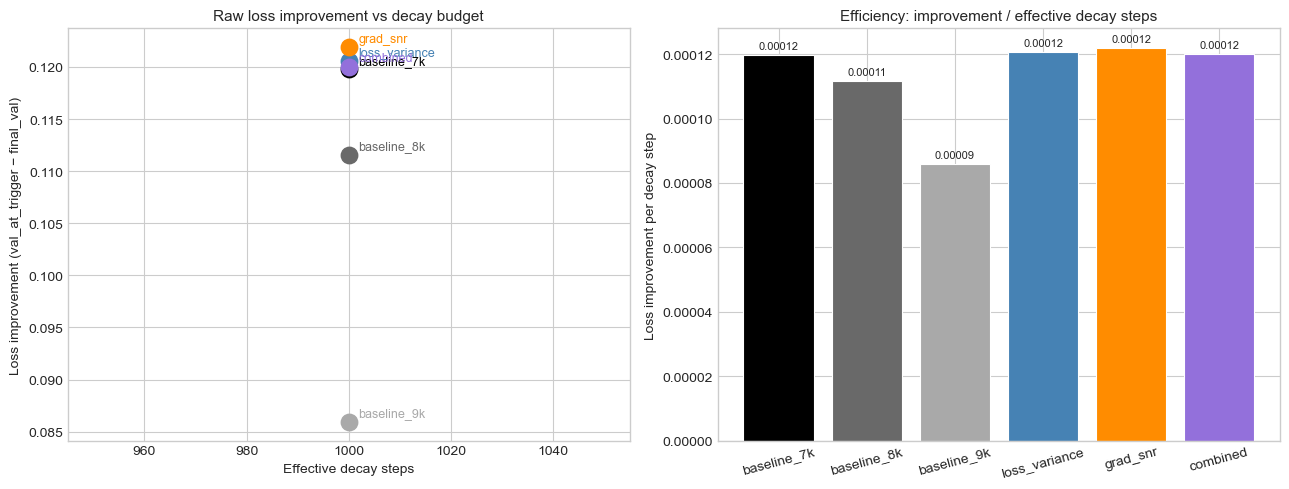

In [31]:
MAX_STEPS = 10000
DECAY_LENGTH = 1000  # adjust if runs use a different decay_length

rows = []
for key, d in data.items():
    trig_step = d["trigger"]["trigger_step"] if d["trigger"] else None
    if trig_step is None:
        continue
    effective_decay_steps = min(DECAY_LENGTH, MAX_STEPS - trig_step)

    val = d["val"]
    before_trigger = val[val["step"] <= trig_step]
    val_at_trigger = before_trigger["validation_loss"].iloc[-1] if len(before_trigger) > 0 else float("nan")

    final_val = val["validation_loss"].iloc[-1]
    improvement = val_at_trigger - final_val

    rows.append({
        "run": key,
        "trigger_step": trig_step,
        "effective_decay_steps": effective_decay_steps,
        "val_at_trigger": val_at_trigger,
        "final_val_loss": final_val,
        "loss_improvement": improvement,
        "improvement_per_step": improvement / effective_decay_steps if effective_decay_steps > 0 else float("nan"),
    })

eff_df = pd.DataFrame(rows).set_index("run")
display(eff_df.style.background_gradient(
    subset=["effective_decay_steps", "loss_improvement", "improvement_per_step"], cmap="RdYlGn"
))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for key, row in eff_df.iterrows():
    ax.scatter(row["effective_decay_steps"], row["loss_improvement"],
               color=COLORS[key], s=140, zorder=4)
    ax.annotate(key, (row["effective_decay_steps"], row["loss_improvement"]),
                textcoords="offset points", xytext=(7, 4), fontsize=9, color=COLORS[key])
ax.set_xlabel("Effective decay steps")
ax.set_ylabel("Loss improvement (val_at_trigger − final_val)")
ax.set_title("Raw loss improvement vs decay budget", fontsize=11)

ax2 = axes[1]
keys = list(eff_df.index)
vals = eff_df["improvement_per_step"].values
colors = [COLORS[k] for k in keys]
bars = ax2.bar(keys, vals, color=colors, edgecolor="white", linewidth=0.8)
ax2.bar_label(bars, fmt="%.5f", fontsize=8, padding=3)
ax2.set_ylabel("Loss improvement per decay step")
ax2.set_title("Efficiency: improvement / effective decay steps", fontsize=11)
ax2.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()
